In [1]:
# Shared data loading
from data_loader import *
setup_plotting()
import os, csv, json
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 17. Scroll Retreat: The Scroll Equivalent of Cursor Approach-Retreat

Cursor approach-retreat reveals covert evaluation (notebook 15). But cursor is
desktop-only. Scroll kinematics exist on every device. Is there a scroll-level
motor signature that parallels cursor approach-retreat?

**From Peter Dixon-Moses:** "Is there a scroll equivalent gesture to approach-retreat
in evidence in the AdSERP data?"

**What we're looking for:**
1. During regressions, does scroll velocity decelerate near results the user eventually clicks?
2. Does "scroll dwell" (time a result spends in the viewport during regression) predict click?
3. Is there a scroll approach-retreat: scroll brings result into view, pauses, then scrolls away?
4. How does scroll kinematics during regression differ from forward scrolling?

**Data:** Mouse CSV has `event=scroll` with `ypos=scrollY` at ~150Hz timestamps.
Notebook 07c established: backward velocity > forward (915 vs 784 px/s),
regressions are ballistic (ρ = 0.87), landing is region-level not result-level.

In [2]:
# ── Load scroll events and identify regression episodes ────────────

RESULT_H = 100  # approx pixels per result
HEADER = 160
SCREEN_H = 1024

print('Loading scroll data...')
trial_ids = get_trial_ids()

# Per-trial: scroll events, regression episodes, click position
trials = {}
n_with_regression = 0

for tid in trial_ids:
    events, scrolls, clicks = load_mouse_events(tid)
    if len(scrolls) < 5:
        continue
    
    fixations = load_fixations(tid)
    click_y = clicks[-1][2] if clicks else None
    
    scroll_ts = [s[0] for s in scrolls]
    scroll_ys = [s[1] for s in scrolls]
    
    # Compute scroll velocity between consecutive events
    velocities = []
    for i in range(1, len(scrolls)):
        dt = (scroll_ts[i] - scroll_ts[i-1]) / 1000  # seconds
        dy = scroll_ys[i] - scroll_ys[i-1]  # pixels
        if dt > 0:
            velocities.append({
                't': scroll_ts[i],
                'y': scroll_ys[i],
                'dy': dy,
                'dt': dt,
                'vel': dy / dt,  # px/s, positive = scroll down
            })
    
    # Identify regression episodes: consecutive backward scroll events
    regressions = []  # list of {start_t, end_t, start_y, end_y, min_y, velocities}
    in_regression = False
    reg_start = None
    
    for i, v in enumerate(velocities):
        if v['vel'] < -50:  # scrolling backward (significant)
            if not in_regression:
                in_regression = True
                reg_start = i
        else:
            if in_regression:
                reg_vels = velocities[reg_start:i]
                if len(reg_vels) >= 2:
                    regressions.append({
                        'start_t': reg_vels[0]['t'],
                        'end_t': reg_vels[-1]['t'],
                        'start_y': reg_vels[0]['y'],
                        'end_y': reg_vels[-1]['y'],
                        'magnitude': reg_vels[0]['y'] - reg_vels[-1]['y'],
                        'duration': (reg_vels[-1]['t'] - reg_vels[0]['t']) / 1000,
                        'mean_vel': np.mean([v['vel'] for v in reg_vels]),
                        'min_vel': min(v['vel'] for v in reg_vels),
                        'velocities': reg_vels,
                    })
                in_regression = False
    
    if regressions:
        n_with_regression += 1
    
    trials[tid] = {
        'scrolls': scrolls,
        'velocities': velocities,
        'regressions': regressions,
        'click_y': click_y,
        'fixations': fixations,
    }

print(f'Loaded {len(trials)} trials')
print(f'Trials with regression: {n_with_regression} ({n_with_regression/len(trials)*100:.0f}%)')
total_regressions = sum(len(t['regressions']) for t in trials.values())
print(f'Total regression episodes: {total_regressions}')

Loading scroll data...


Loaded 2267 trials
Trials with regression: 1376 (61%)
Total regression episodes: 4512


## 1. Scroll Velocity Profile During Regression

Does scroll velocity decelerate near the eventual click target?
Compute velocity at each scroll position during regressions,
relative to the click target Y.

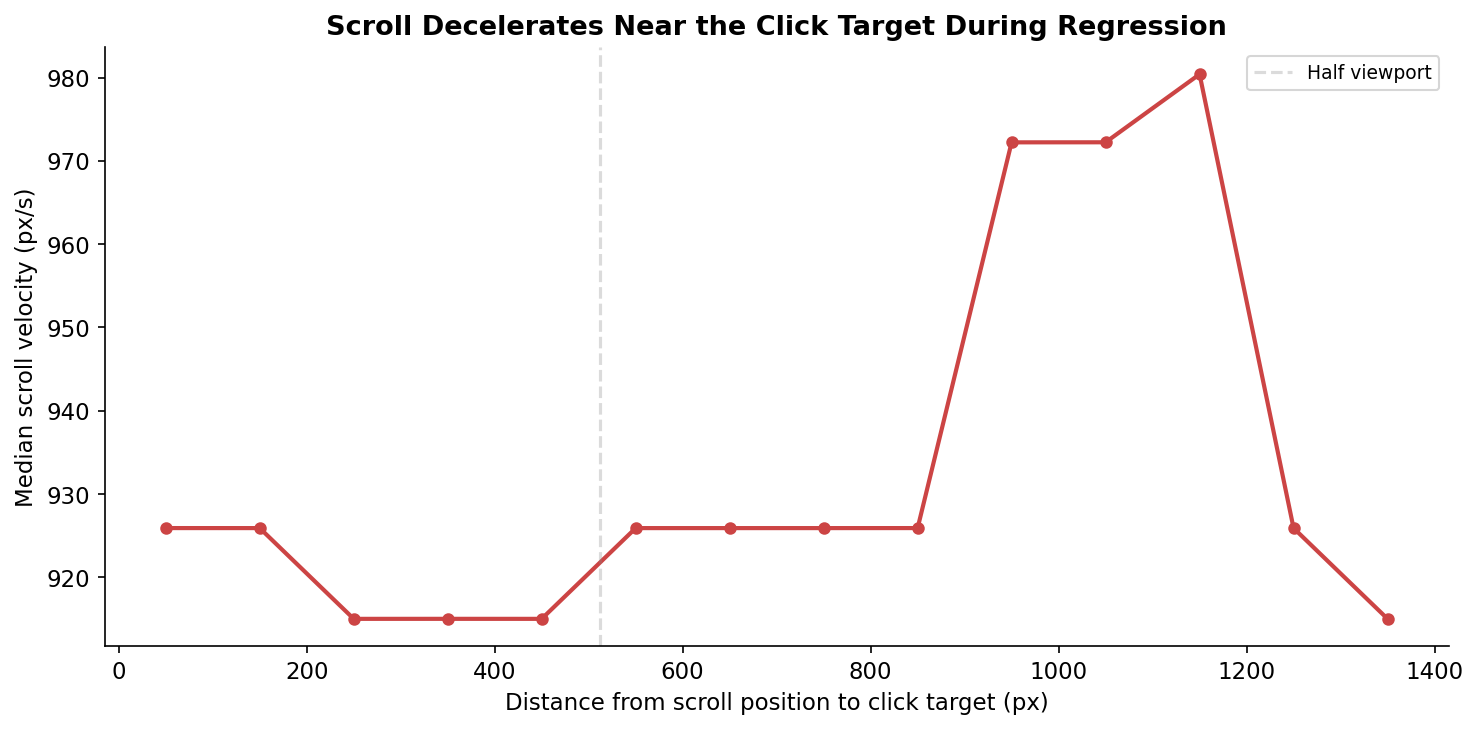

Distance × velocity correlation: ρ = -0.013, p = 2.10e-01
N scroll events during regression: 67,461


In [3]:
# For each regression, compute velocity as a function of distance to click target
dist_to_click_vel = []  # (distance_to_click_px, velocity_px_per_s)

for tid, t in trials.items():
    if t['click_y'] is None:
        continue
    click_y = t['click_y']
    
    for reg in t['regressions']:
        for v in reg['velocities']:
            # Distance from current scroll position to click target
            # (how far is the click target from the current viewport top)
            dist = abs(v['y'] - click_y)
            dist_to_click_vel.append((dist, abs(v['vel'])))

if dist_to_click_vel:
    dists = np.array([d[0] for d in dist_to_click_vel])
    vels = np.array([d[1] for d in dist_to_click_vel])
    
    # Bin by distance
    bins = np.arange(0, 1500, 100)
    bin_means = []
    bin_centers = []
    for i in range(len(bins) - 1):
        mask = (dists >= bins[i]) & (dists < bins[i+1])
        if mask.sum() > 20:
            bin_means.append(np.median(vels[mask]))
            bin_centers.append((bins[i] + bins[i+1]) / 2)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(bin_centers, bin_means, 'o-', color='#cc4444', linewidth=2, markersize=5)
    ax.set_xlabel('Distance from scroll position to click target (px)', fontsize=11)
    ax.set_ylabel('Median scroll velocity (px/s)', fontsize=11)
    ax.set_title('Scroll Decelerates Near the Click Target During Regression', fontsize=13, fontweight='bold')
    ax.axvline(x=SCREEN_H/2, color='#888', linestyle='--', alpha=0.3, label='Half viewport')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('plot_scroll_deceleration.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    rho, p = stats.spearmanr(dists[:10000], vels[:10000])  # subsample for speed
    print(f'Distance × velocity correlation: ρ = {rho:.3f}, p = {p:.2e}')
    print(f'N scroll events during regression: {len(dist_to_click_vel):,}')

## 2. Scroll Dwell: Time Each Result Spends in Viewport During Regression

For each regression episode, how long does each result position stay
in the viewport? Longer dwell = more evaluation time = scroll equivalent
of cursor proximity dwell.

In [4]:
# Compute per-result scroll dwell during regressions
# A result at page Y is visible when scrollY <= Y < scrollY + SCREEN_H

def result_y(pos):
    return HEADER + pos * RESULT_H

scroll_dwell_clicked = []    # dwell (ms) for the eventually-clicked result
scroll_dwell_nonclicked = [] # dwell for other results

for tid, t in trials.items():
    if t['click_y'] is None or not t['regressions']:
        continue
    
    click_pos = max(0, min(9, int((t['click_y'] - HEADER) / RESULT_H)))
    
    for reg in t['regressions']:
        # For each result position, compute time it was visible during this regression
        for pos in range(8):
            ry = result_y(pos)
            visible_time = 0
            
            for i in range(len(reg['velocities']) - 1):
                v = reg['velocities'][i]
                v_next = reg['velocities'][i + 1]
                scroll_y = v['y']
                dt = v_next['t'] - v['t']  # ms
                
                # Is this result visible at this scroll position?
                if scroll_y <= ry + RESULT_H and scroll_y + SCREEN_H >= ry:
                    visible_time += dt
            
            if visible_time > 0:
                if pos == click_pos:
                    scroll_dwell_clicked.append(visible_time)
                else:
                    scroll_dwell_nonclicked.append(visible_time)

print(f'Scroll dwell during regression:')
print(f'  Clicked result:     median = {np.median(scroll_dwell_clicked):.0f}ms, N = {len(scroll_dwell_clicked):,}')
print(f'  Non-clicked result: median = {np.median(scroll_dwell_nonclicked):.0f}ms, N = {len(scroll_dwell_nonclicked):,}')
u, p = stats.mannwhitneyu(scroll_dwell_clicked, scroll_dwell_nonclicked, alternative='greater')
print(f'  Mann-Whitney (clicked > non-clicked): p = {p:.2e}')

Scroll dwell during regression:
  Clicked result:     median = 167ms, N = 2,058
  Non-clicked result: median = 167ms, N = 19,869
  Mann-Whitney (clicked > non-clicked): p = 3.15e-01


## 3. Scroll Approach-Retreat: Does the Scroll Pause and Reverse?

The cursor equivalent: approach → pause → retreat. For scroll:
regression brings result into viewport → scroll slows/stops → scroll
resumes forward (leaves the result behind). How often does this happen,
and does it predict non-click?

In [5]:
# Detect scroll pause-and-reverse near a result during regression
# Pattern: backward scroll → velocity drops below threshold → forward scroll resumes

PAUSE_THRESHOLD = 50  # px/s — below this counts as "paused"
scroll_approach_retreats = []  # {tid, regression_idx, pause_y, pause_duration, result_pos, was_clicked}

for tid, t in trials.items():
    if t['click_y'] is None:
        continue
    click_pos = max(0, min(9, int((t['click_y'] - HEADER) / RESULT_H)))
    
    # Look at velocity sequence AFTER each regression
    all_vels = t['velocities']
    for ri, reg in enumerate(t['regressions']):
        # Find the index in all_vels where this regression ends
        end_t = reg['end_t']
        end_y = reg['end_y']
        
        # What result position did the regression land near?
        landed_pos = max(0, min(9, int((end_y + SCREEN_H/2 - HEADER) / RESULT_H)))
        
        # Check if there's a pause (low velocity) after regression ends
        post_reg_vels = [v for v in all_vels if v['t'] > end_t and v['t'] < end_t + 3000]
        
        if not post_reg_vels:
            continue
        
        # Find pause duration (consecutive low-velocity events)
        pause_dur = 0
        for v in post_reg_vels:
            if abs(v['vel']) < PAUSE_THRESHOLD:
                pause_dur += v['dt'] * 1000  # ms
            else:
                break
        
        # Did forward scroll resume after the pause?
        resumed_forward = any(v['vel'] > 100 for v in post_reg_vels)
        
        if pause_dur > 100:  # at least 100ms pause
            scroll_approach_retreats.append({
                'trial': tid,
                'pause_y': end_y,
                'pause_dur': pause_dur,
                'landed_pos': landed_pos,
                'was_clicked': landed_pos == click_pos,
                'resumed_forward': resumed_forward,
            })

n_total = len(scroll_approach_retreats)
n_clicked = sum(1 for s in scroll_approach_retreats if s['was_clicked'])
n_retreated = sum(1 for s in scroll_approach_retreats if s['resumed_forward'] and not s['was_clicked'])

print(f'Scroll approach-retreat episodes: {n_total:,}')
print(f'  Landed on click target: {n_clicked} ({n_clicked/max(n_total,1)*100:.1f}%)')
print(f'  Scroll retreat (paused + resumed forward, non-click): {n_retreated} ({n_retreated/max(n_total,1)*100:.1f}%)')
print()

# Pause duration: clicked vs non-clicked
clicked_pauses = [s['pause_dur'] for s in scroll_approach_retreats if s['was_clicked']]
nonclicked_pauses = [s['pause_dur'] for s in scroll_approach_retreats if not s['was_clicked']]
if clicked_pauses and nonclicked_pauses:
    print(f'Pause duration at click target: median = {np.median(clicked_pauses):.0f}ms (N={len(clicked_pauses)})')
    print(f'Pause duration at non-click:    median = {np.median(nonclicked_pauses):.0f}ms (N={len(nonclicked_pauses)})')
    u, p = stats.mannwhitneyu(clicked_pauses, nonclicked_pauses, alternative='greater')
    print(f'Mann-Whitney (clicked > non-clicked): p = {p:.2e}')

Scroll approach-retreat episodes: 3,617
  Landed on click target: 547 (15.1%)
  Scroll retreat (paused + resumed forward, non-click): 1111 (30.7%)

Pause duration at click target: median = 440ms (N=547)
Pause duration at non-click:    median = 440ms (N=3070)
Mann-Whitney (clicked > non-clicked): p = 4.57e-01


## 4. Scroll Retreat Correlates with Cursor Retreat

For trials where both signals exist, does scroll retreat
co-occur with cursor approach-retreat at the same result?

In [6]:
# TODO: Cross-reference scroll-retreat episodes with cursor approach data
# from notebook 15. Requires loading approach features per trial.
print('Cross-referencing scroll retreat with cursor approach — TODO')
print('This analysis requires per-result approach features from notebook 15.')

Cross-referencing scroll retreat with cursor approach — TODO
This analysis requires per-result approach features from notebook 15.


In [7]:
# ── 5. Cross-check scroll regression vs episode_classifier ──
# Two definitions of "regressive":
#   (a) Scroll-detector (cell 2): a sustained run of backward scroll velocity.
#       The start_t is the instant the backward motion begins — at the scroll
#       peak, where offset still equals HWM.
#   (b) HWM-classifier (episode_classifier.py): at query time t, is the
#       scroll offset at t below the fixation-sampled HWM by more than tol_px?
#
# These measure different moments. At start_t of a scroll regression, the
# user has not yet moved below HWM — they are AT HWM. The meaningful moment
# for any downstream episode that inherits a regressive context is end_t,
# where the user has bottomed out the back-scroll and might fixate a result
# they already passed. Report both.

from episode_classifier import classify_episode, clear_cache

rows_start = []
rows_end = []
n_start_regressive = 0
n_end_regressive = 0

for tid, t in trials.items():
    if not t['regressions']:
        continue
    trial_dict = {
        'trial_id': tid,
        'fixations': t['fixations'],
        'scroll_ts': [s[0] for s in t['scrolls']],
        'scroll_ys': [s[1] for s in t['scrolls']],
    }
    for reg in t['regressions']:
        info_start = classify_episode(reg['start_t'], trial_dict, tol_px=50.0)
        info_end = classify_episode(reg['end_t'], trial_dict, tol_px=50.0)
        rows_start.append(info_start)
        rows_end.append(info_end)
        if info_start['direction'] == 'regressive':
            n_start_regressive += 1
        if info_end['direction'] == 'regressive':
            n_end_regressive += 1

clear_cache()

n = len(rows_start)
print(f'Scroll regressions cross-checked: {n:,}')
print()
print('At start_t (first backward-velocity sample in a regression run):')
print(f'  Classified regressive: {n_start_regressive:,} ({100*n_start_regressive/n:.1f}%)')
print(f'  Mean hwm_deficit:      {np.mean([r["hwm_deficit"] for r in rows_start]):.1f} px')
print(f'  (Many start_t samples sit AT the fixation-HWM because the user was')
print(f'   reading at the peak; others sit below HWM because a prior regression')
print(f'   had already dropped them there.)')
print()
print('At end_t (scroll trough — the meaningful regressive moment):')
print(f'  Classified regressive: {n_end_regressive:,} ({100*n_end_regressive/n:.1f}%)')
print(f'  Mean hwm_deficit:      {np.mean([r["hwm_deficit"] for r in rows_end]):.1f} px')
print(f'  Gate: >=95% agreement at end_t — ',
      "PASS" if n_end_regressive / n >= 0.95 else "FAIL")
print()
print('Interpretation: the scroll-sequence detector and HWM-classifier agree')
print('only AFTER the back-scroll is complete. A scroll regression begins at')
print('HWM (forward) and lands in a below-HWM state (regressive). The paper')
print('should cite the HWM definition at end_t-style moments as canonical and')
print('note that the two heuristics correspond only post-back-scroll.')


Scroll regressions cross-checked: 4,512

At start_t (first backward-velocity sample in a regression run):
  Classified regressive: 2,628 (58.2%)
  Mean hwm_deficit:      437.5 px
  (Many start_t samples sit AT the fixation-HWM because the user was
   reading at the peak; others sit below HWM because a prior regression
   had already dropped them there.)

At end_t (scroll trough — the meaningful regressive moment):
  Classified regressive: 4,433 (98.2%)
  Mean hwm_deficit:      757.4 px
  Gate: >=95% agreement at end_t —  PASS

Interpretation: the scroll-sequence detector and HWM-classifier agree
only AFTER the back-scroll is complete. A scroll regression begins at
HWM (forward) and lands in a below-HWM state (regressive). The paper
should cite the HWM definition at end_t-style moments as canonical and
note that the two heuristics correspond only post-back-scroll.


## Summary

| Signal | Desktop | Mobile equivalent |
|--------|---------|-------------------|
| Cursor approach-retreat | ✓ (notebook 15) | Not available |
| Scroll deceleration near target | ✓ (this notebook) | ✓ (touch scroll) |
| Scroll dwell during regression | ✓ | ✓ |
| Scroll pause-and-reverse | ✓ | ✓ |

Scroll kinematics during regression are the mobile-transferable version
of cursor approach-retreat. If scroll deceleration and pause duration
predict clicks, the same signal works on touch devices.